In [20]:
from typing import Annotated
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.prebuilt import ToolNode, tools_condition
import requests
import os
from langchain_openai import ChatOpenAI
from typing import TypedDict
from langchain_anthropic import AnthropicLLM, ChatAnthropic
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_core.tools import Tool

from langgraph.checkpoint.memory import MemorySaver
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver
import nest_asyncio
from langchain_community.agent_toolkits import PlayWrightBrowserToolkit
from langchain_community.tools.playwright.utils import create_async_playwright_browser


In [2]:
import sys
print(sys.executable)

/Users/vedmuthal/Downloads/personal_agents/.venv/bin/python


In [3]:
load_dotenv(override=True)

True

In [4]:
serper = GoogleSerperAPIWrapper()
serper.run("What is the capital of India?")

"New Delhi is the capital of India and a part of the National Capital Territory of Delhi (NCT). New Delhi is the seat of all three branches of the Government ... Delhi, a city and union territory, is the national capital of India, located in the north-central part of the country. It consists of two main ... Thus, in 1911, New Delhi became the capital of India, south of the Old City of Delhi. And then over the years, Delhi expanded, and satellite ... From its origins as 'Indraprastha' in the Mahabharata to becoming the capital in 1911, Delhi blends ancient charm and modern governance. Delhi, officially the National Capital Territory (NCT) of Delhi, is a city and a union territory of India containing New Delhi, the capital of India. What's The Capital Of India? Pt.346. 149. Dislike. 8. Share. Video unavailable. This content isn't available. Skip video. The capital of India is New Delhi, located in the north-central part of the country to the west of the Yamuna River. But the Indian const

In [5]:
tool_search = Tool(
    name="search",
    func=serper.run,
    description="Useful for when you need more info from an Online Search"
)

In [6]:
tool_search.invoke("What is the capital of India?")

"New Delhi is the capital of India and a part of the National Capital Territory of Delhi (NCT). New Delhi is the seat of all three branches of the Government ... Delhi, a city and union territory, is the national capital of India, located in the north-central part of the country. It consists of two main ... Delhi, officially the National Capital Territory (NCT) of Delhi, is a city and a union territory of India containing New Delhi, the capital of India. From its origins as 'Indraprastha' in the Mahabharata to becoming the capital in 1911, Delhi blends ancient charm and modern governance. Thus, in 1911, New Delhi became the capital of India, south of the Old City of Delhi. And then over the years, Delhi expanded, and satellite ... What is the Capital of India? Capital City, New Delhi. Capital location, 28 36 N, 77 12 E. Capital - history, the city's name is associated with various myths ... The capital of India is New Delhi, where national governance is based. As travelers, explore maj

In [7]:
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_user = os.getenv("PUSHOVER_USER")
pushover_url = "https://api.pushover.net/1/messages.json"

def push(text: str):
    """Send a push message."""
    requests.post(pushover_url, data={"token": pushover_token, "user": pushover_user, "message": text})

In [8]:
tool_push = Tool(
    name="send_push_notification",
    func=push,
    description="Useful for when you want to send a push notification",
)

tool_push.invoke("What is the capital of India?")

In [9]:
tools = [tool_search, tool_push]

In [10]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [11]:
graph_builder = StateGraph(State)

In [12]:
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

In [13]:
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

In [14]:
graph_builder.add_conditional_edges("chatbot", tools_condition, "tools")

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

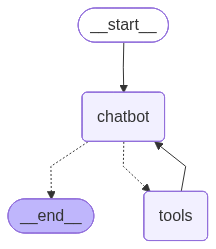

In [15]:
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
# config = {"configurable": {"thread_id": "1"}}
#
# def chat(user_input: str, history):
#     result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
#     return result["messages"][-1].content
#
# gr.ChatInterface(chat).launch()

In [17]:
db_path = "memory.db"
conn = sqlite3.connect(db_path, check_same_thread=False)
sql_memory = SqliteSaver(conn)

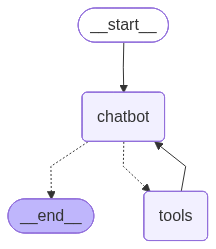

In [18]:
graph_builder = StateGraph(State)

llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

graph_builder.add_conditional_edges("chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

graph = graph_builder.compile(checkpointer=sql_memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
config = {"configurable": {"thread_id": "7"}}

def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content

gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
